# Kaggle Predict F1 Pit Stops: Model Optimization and Ensemble

LightGBM tuning, feature-set validation, and LightGBM/XGBoost probability blending.


## LightGBM Tuning


## 1. Setup

In [1]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10, "legend.frameon": False})

RANDOM_STATE = 42
TARGET = "PitNextLap"
ID_COL = "id"

# Use FAST mode for quick iteration, then set False for the final tuning run.
RUN_FAST = True
FAST_SAMPLE_SIZE = 180_000
N_SPLITS = 5
N_ITER = 12 if RUN_FAST else 30

## 2. Load Data

In [2]:
def find_data_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e5"),
        Path("/kaggle/input/playground-series-s6e5"),
        Path("../input/competitions/playground-series-s6e5"),
        Path("../input/playground-series-s6e5"),
        Path("data"),
        Path("../data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists() and (path / "test.csv").exists():
            return path
    raise FileNotFoundError("Could not find train.csv and test.csv. Update DATA_DIR manually.")


def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = reduce_memory_usage(pd.read_csv(DATA_DIR / "train.csv"))
test = reduce_memory_usage(pd.read_csv(DATA_DIR / "test.csv"))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"DATA_DIR: {DATA_DIR}")
print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"target positive rate: {train[TARGET].mean():.5f}")

DATA_DIR: /kaggle/input/competitions/playground-series-s6e5
train: (439140, 16)
test: (188165, 15)
target positive rate: 0.19898


## 3. Feature Engineering

In [3]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-6

    if {"LapNumber", "RaceProgress"}.issubset(out.columns):
        out["EstimatedRaceLaps"] = out["LapNumber"] / out["RaceProgress"].clip(lower=eps)
        out["EstimatedLapsRemaining"] = out["EstimatedRaceLaps"] - out["LapNumber"]
        out["LapNumber_x_RaceProgress"] = out["LapNumber"] * out["RaceProgress"]

    if {"TyreLife", "LapNumber"}.issubset(out.columns):
        out["TyreLife_to_LapNumber"] = out["TyreLife"] / out["LapNumber"].clip(lower=eps)

    if {"TyreLife", "EstimatedRaceLaps"}.issubset(out.columns):
        out["TyreLife_to_EstimatedRaceLaps"] = out["TyreLife"] / out["EstimatedRaceLaps"].clip(lower=eps)

    if {"LapTime (s)", "LapTime_Delta"}.issubset(out.columns):
        out["LapTime_plus_Delta"] = out["LapTime (s)"] + out["LapTime_Delta"]
        out["AbsLapTime_Delta"] = out["LapTime_Delta"].abs()

    if {"Position", "Position_Change"}.issubset(out.columns):
        out["PreviousPositionApprox"] = out["Position"] - out["Position_Change"]
        out["AbsPosition_Change"] = out["Position_Change"].abs()

    if "Compound" in out.columns:
        compound = out["Compound"].astype(str)
        out["IsSoft"] = (compound == "SOFT").astype("int8")
        out["IsMedium"] = (compound == "MEDIUM").astype("int8")
        out["IsHard"] = (compound == "HARD").astype("int8")
        out["IsWetOrIntermediate"] = compound.isin(["WET", "INTERMEDIATE"]).astype("int8")

    return reduce_memory_usage(out)


train_fe = add_features(train)
test_fe = add_features(test)

if RUN_FAST and len(train_fe) > FAST_SAMPLE_SIZE:
    train_fe = (
        train_fe.groupby(TARGET, group_keys=False)
        .apply(lambda x: x.sample(frac=min(1.0, FAST_SAMPLE_SIZE / len(train)), random_state=RANDOM_STATE))
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    print(f"RUN_FAST sample shape: {train_fe.shape}")

X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET].astype("int8")
X_test = test_fe.copy()

print("Features:", X.shape[1])
print("Positive rate:", y.mean())

RUN_FAST sample shape: (180000, 29)
Features: 28
Positive rate: 0.19898333333333335


## 4. Preprocessing and Scoring

In [4]:
def get_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    features = df.drop(columns=[c for c in [ID_COL] if c in df.columns])
    cat_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in features.columns if c not in cat_cols]
    return num_cols, cat_cols


def make_preprocessor(df: pd.DataFrame) -> ColumnTransformer:
    num_cols, cat_cols = get_feature_columns(df)
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")


def evaluate_predictions(y_true, y_pred) -> dict:
    y_pred = np.clip(y_pred, 1e-6, 1 - 1e-6)
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_pred),
    }


preprocessor = make_preprocessor(X)
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

## 5. Hyperparameter Search

In [5]:
base_params = {
    "objective": "binary",
    "n_estimators": 900 if RUN_FAST else 1800,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

param_grid = {
    "learning_rate": [0.015, 0.02, 0.03, 0.04, 0.05],
    "num_leaves": [31, 47, 63, 95, 127],
    "min_child_samples": [20, 40, 60, 100, 150],
    "subsample": [0.75, 0.85, 0.95, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.03, 0.1, 0.3, 1.0],
    "reg_lambda": [0.3, 1.0, 2.0, 5.0, 10.0],
    "max_bin": [127, 255, 511],
}

candidate_params = list(ParameterSampler(param_grid, n_iter=N_ITER, random_state=RANDOM_STATE))
print(f"Testing {len(candidate_params)} LightGBM configurations")

Testing 12 LightGBM configurations


In [6]:
def cross_validate_lgbm(params: dict, candidate_id: int) -> dict:
    start = time.time()
    oof = np.zeros(len(X), dtype=np.float32)
    fold_rows = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        fold_preprocessor = make_preprocessor(X_train_raw)
        X_train = fold_preprocessor.fit_transform(X_train_raw)
        X_valid = fold_preprocessor.transform(X_valid_raw)

        model = LGBMClassifier(**base_params, **params)
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_valid)[:, 1]
        oof[valid_idx] = pred

        scores = evaluate_predictions(y_valid, pred)
        scores.update({"candidate": candidate_id, "fold": fold})
        fold_rows.append(scores)

        del fold_preprocessor, X_train, X_valid, model
        gc.collect()

    overall = evaluate_predictions(y, oof)
    overall.update({"candidate": candidate_id, "fold": "oof", "fit_seconds": time.time() - start})
    overall.update(params)
    return overall, fold_rows, oof


search_rows = []
fold_rows_all = []
best_oof = None
best_score = -np.inf

for candidate_id, params in enumerate(candidate_params, start=1):
    print(f"\nCandidate {candidate_id}/{len(candidate_params)}: {params}")
    result, fold_rows, oof = cross_validate_lgbm(params, candidate_id)
    search_rows.append(result)
    fold_rows_all.extend(fold_rows)

    if result["roc_auc"] > best_score:
        best_score = result["roc_auc"]
        best_oof = oof.copy()

    print(
        f"OOF auc={result['roc_auc']:.5f}, "
        f"ap={result['average_precision']:.5f}, "
        f"logloss={result['log_loss']:.5f}, "
        f"seconds={result['fit_seconds']:.1f}"
    )

search_results = pd.DataFrame(search_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
fold_results = pd.DataFrame(fold_rows_all)
search_results.head(10)


Candidate 1/12: {'subsample': 0.95, 'reg_lambda': 10.0, 'reg_alpha': 0.1, 'num_leaves': 127, 'min_child_samples': 100, 'max_bin': 127, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
OOF auc=0.94684, ap=0.80299, logloss=0.23022, seconds=93.0

Candidate 2/12: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.3, 'num_leaves': 95, 'min_child_samples': 100, 'max_bin': 255, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
OOF auc=0.94597, ap=0.79892, logloss=0.23265, seconds=78.7

Candidate 3/12: {'subsample': 0.75, 'reg_lambda': 5.0, 'reg_alpha': 0.03, 'num_leaves': 127, 'min_child_samples': 100, 'max_bin': 255, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
OOF auc=0.94677, ap=0.80249, logloss=0.23043, seconds=98.1

Candidate 4/12: {'subsample': 0.95, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'num_leaves': 47, 'min_child_samples': 60, 'max_bin': 511, 'learning_rate': 0.04, 'colsample_bytree': 0.9}
OOF auc=0.94670, ap=0.80200, logloss=0.23054, seconds=70.4

Candidate 5/12: {'subsample': 1.0

,roc_auc,average_precision,log_loss,candidate,fold,fit_seconds,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_bin,learning_rate,colsample_bytree
0,0.947282,0.804845,0.229346,9,oof,105.349954,0.95,10.0,1.00,127,150,255,0.020,0.9
1,0.947248,0.804297,0.229308,7,oof,73.523304,0.95,1.0,1.00,95,150,127,0.030,0.8
2,0.946837,0.802986,0.230223,1,oof,93.006412,0.95,10.0,0.10,127,100,127,0.020,1.0
3,0.946818,0.802110,0.230353,8,oof,75.962245,0.85,10.0,0.03,95,150,127,0.040,1.0
4,0.946775,0.802490,0.230429,3,oof,98.127371,0.75,5.0,0.03,127,100,255,0.030,1.0
5,0.946697,0.801996,0.230545,4,oof,70.366993,0.95,5.0,1.00,47,60,511,0.040,0.9
6,0.946450,0.800509,0.230997,6,oof,74.028143,0.75,2.0,0.30,63,20,511,0.050,0.9
7,0.946295,0.800464,0.231357,11,oof,101.910965,0.75,1.0,0.03,95,60,511,0.020,1.0
8,0.946254,0.801455,0.231550,5,oof,113.614655,1.00,10.0,0.30,95,150,511,0.015,1.0
9,0.945968,0.798919,0.232650,2,oof,78.719450,1.00,1.0,0.30,95,100,255,0.050,1.0


## 6. Review Tuning Results

,candidate,roc_auc,average_precision,log_loss,fit_seconds,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_bin,learning_rate,colsample_bytree
0,9,0.947282,0.804845,0.229346,105.349954,0.95,10.0,1.00,127,150,255,0.020,0.9
1,7,0.947248,0.804297,0.229308,73.523304,0.95,1.0,1.00,95,150,127,0.030,0.8
2,1,0.946837,0.802986,0.230223,93.006412,0.95,10.0,0.10,127,100,127,0.020,1.0
3,8,0.946818,0.802110,0.230353,75.962245,0.85,10.0,0.03,95,150,127,0.040,1.0
4,3,0.946775,0.802490,0.230429,98.127371,0.75,5.0,0.03,127,100,255,0.030,1.0
5,4,0.946697,0.801996,0.230545,70.366993,0.95,5.0,1.00,47,60,511,0.040,0.9
6,6,0.946450,0.800509,0.230997,74.028143,0.75,2.0,0.30,63,20,511,0.050,0.9
7,11,0.946295,0.800464,0.231357,101.910965,0.75,1.0,0.03,95,60,511,0.020,1.0
8,5,0.946254,0.801455,0.231550,113.614655,1.00,10.0,0.30,95,150,511,0.015,1.0
9,2,0.945968,0.798919,0.232650,78.719450,1.00,1.0,0.30,95,100,255,0.050,1.0


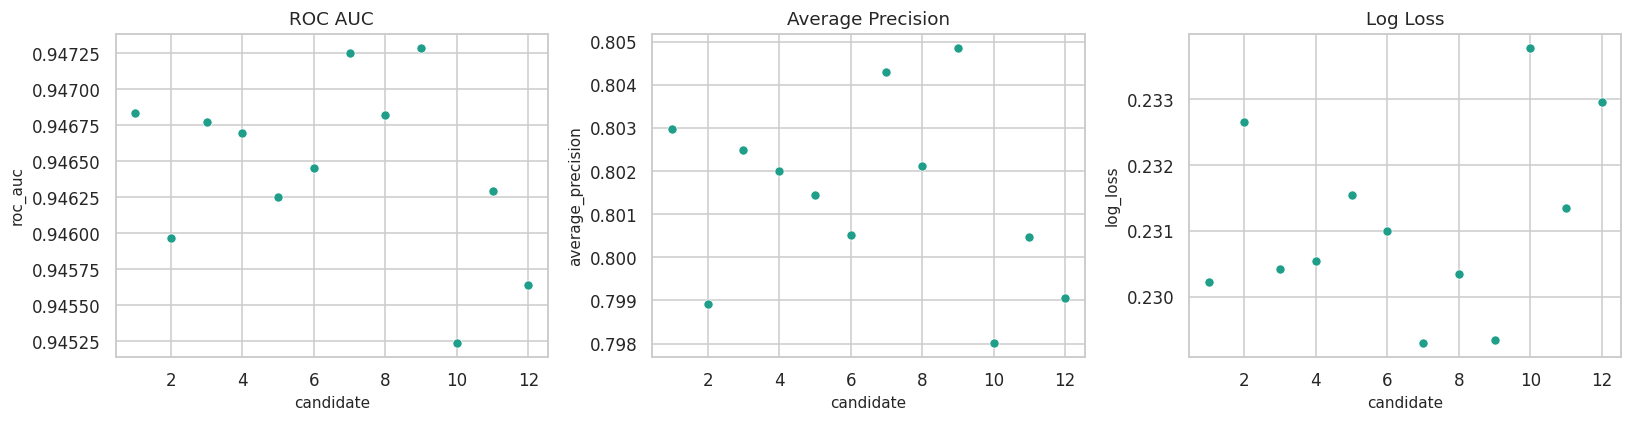

In [7]:
metric_cols = ["roc_auc", "average_precision", "log_loss", "fit_seconds"]
param_cols = [c for c in search_results.columns if c not in metric_cols + ["candidate", "fold"]]
display(search_results[["candidate"] + metric_cols + param_cols].head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes, ["roc_auc", "average_precision", "log_loss"], ["ROC AUC", "Average Precision", "Log Loss"]):
    sns.scatterplot(data=search_results, x="candidate", y=metric, color=sns.color_palette("viridis", 8)[4], ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 7. Train Best Model and Submit

In [8]:
best_row = search_results.iloc[0]
best_params = {col: best_row[col] for col in param_grid.keys()}
print("Best candidate:", int(best_row["candidate"]))
print("Best OOF ROC AUC:", round(best_row["roc_auc"], 6))
print("Best params:", best_params)

final_preprocessor = make_preprocessor(X)
X_train_all = final_preprocessor.fit_transform(X)
X_test_all = final_preprocessor.transform(X_test)

final_model = LGBMClassifier(**base_params, **best_params)
final_model.fit(X_train_all, y)

test_pred = final_model.predict_proba(X_test_all)[:, 1]
test_pred = np.clip(test_pred, 1e-6, 1 - 1e-6)

submission = sample_submission.copy()
submission[TARGET] = test_pred
submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

search_results.to_csv(OUTPUT_DIR / "lightgbm_tuning_results.csv", index=False)
fold_results.to_csv(OUTPUT_DIR / "lightgbm_tuning_fold_results.csv", index=False)

print("Saved:", submission_path)
submission.head()

Best candidate: 9
Best OOF ROC AUC: 0.947282
Best params: {'learning_rate': np.float64(0.02), 'num_leaves': np.int64(127), 'min_child_samples': np.int64(150), 'subsample': np.float64(0.95), 'colsample_bytree': np.float64(0.9), 'reg_alpha': np.float64(1.0), 'reg_lambda': np.float64(10.0), 'max_bin': np.int64(255)}
Saved: /kaggle/working/submission.csv


,id,PitNextLap
0,439140,0.004559
1,439141,0.002991
2,439142,0.001851
3,439143,0.154017
4,439144,0.849321


## 8. Follow-Up Ideas

- Re-run with `RUN_FAST = False` before trusting the final ranking.
- If tuned LightGBM improves only marginally, spend more time on feature sets and validation diagnostics.
- Compare with an XGBoost tuning notebook only if full-data LightGBM does not clearly separate.
- Add calibration analysis if the competition metric rewards probability quality directly.

## Feature Validation


## 1. Setup

In [9]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10, "legend.frameon": False})

RANDOM_STATE = 42
TARGET = "PitNextLap"
ID_COL = "id"

# Keep True for quick validation. Set False for final evidence.
RUN_FAST = True
FAST_SAMPLE_SIZE = 180_000
N_SPLITS = 5

## 2. Load Data

In [10]:
def find_data_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e5"),
        Path("/kaggle/input/playground-series-s6e5"),
        Path("../input/competitions/playground-series-s6e5"),
        Path("../input/playground-series-s6e5"),
        Path("data"),
        Path("../data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists() and (path / "test.csv").exists():
            return path
    raise FileNotFoundError("Could not find train.csv and test.csv. Update DATA_DIR manually.")


def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = reduce_memory_usage(pd.read_csv(DATA_DIR / "train.csv"))
test = reduce_memory_usage(pd.read_csv(DATA_DIR / "test.csv"))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

if RUN_FAST and len(train) > FAST_SAMPLE_SIZE:
    train_eval = (
        train.groupby(TARGET, group_keys=False)
        .apply(lambda x: x.sample(frac=min(1.0, FAST_SAMPLE_SIZE / len(train)), random_state=RANDOM_STATE))
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    train_eval = train.copy()

print(f"DATA_DIR: {DATA_DIR}")
print(f"train_eval: {train_eval.shape}")
print(f"test: {test.shape}")
print(f"target positive rate: {train_eval[TARGET].mean():.5f}")

DATA_DIR: /kaggle/input/competitions/playground-series-s6e5
train_eval: (180000, 16)
test: (188165, 15)
target positive rate: 0.19898


## 3. Feature Sets

In [11]:
def add_features(df: pd.DataFrame, include_safe: bool = True, include_ratios: bool = True) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-6

    if include_safe and {"LapNumber", "RaceProgress"}.issubset(out.columns):
        out["EstimatedRaceLaps"] = out["LapNumber"] / out["RaceProgress"].clip(lower=eps)
        out["EstimatedLapsRemaining"] = out["EstimatedRaceLaps"] - out["LapNumber"]
        out["LapNumber_x_RaceProgress"] = out["LapNumber"] * out["RaceProgress"]

    if include_ratios and {"TyreLife", "LapNumber"}.issubset(out.columns):
        out["TyreLife_to_LapNumber"] = out["TyreLife"] / out["LapNumber"].clip(lower=eps)

    if include_ratios and {"TyreLife", "EstimatedRaceLaps"}.issubset(out.columns):
        out["TyreLife_to_EstimatedRaceLaps"] = out["TyreLife"] / out["EstimatedRaceLaps"].clip(lower=eps)

    if include_safe and {"LapTime (s)", "LapTime_Delta"}.issubset(out.columns):
        out["LapTime_plus_Delta"] = out["LapTime (s)"] + out["LapTime_Delta"]
        out["AbsLapTime_Delta"] = out["LapTime_Delta"].abs()

    if include_safe and {"Position", "Position_Change"}.issubset(out.columns):
        out["PreviousPositionApprox"] = out["Position"] - out["Position_Change"]
        out["AbsPosition_Change"] = out["Position_Change"].abs()

    if include_safe and "Compound" in out.columns:
        compound = out["Compound"].astype(str)
        out["IsSoft"] = (compound == "SOFT").astype("int8")
        out["IsMedium"] = (compound == "MEDIUM").astype("int8")
        out["IsHard"] = (compound == "HARD").astype("int8")
        out["IsWetOrIntermediate"] = compound.isin(["WET", "INTERMEDIATE"]).astype("int8")

    return reduce_memory_usage(out)


feature_set_configs = {
    "raw": {"include_safe": False, "include_ratios": False, "drop_cols": []},
    "safe_engineered": {"include_safe": True, "include_ratios": False, "drop_cols": []},
    "safe_plus_ratios": {"include_safe": True, "include_ratios": True, "drop_cols": []},
    "safe_plus_ratios_no_driver": {"include_safe": True, "include_ratios": True, "drop_cols": ["Driver"]},
    "safe_plus_ratios_no_pitstop": {"include_safe": True, "include_ratios": True, "drop_cols": ["PitStop"]},
}

list(feature_set_configs)

['raw',
 'safe_engineered',
 'safe_plus_ratios',
 'safe_plus_ratios_no_driver',
 'safe_plus_ratios_no_pitstop']

## 4. Model and Evaluation Helpers

In [12]:
def get_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    features = df.drop(columns=[c for c in [TARGET, ID_COL] if c in df.columns])
    cat_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in features.columns if c not in cat_cols]
    return num_cols, cat_cols


def make_preprocessor(df: pd.DataFrame) -> ColumnTransformer:
    num_cols, cat_cols = get_feature_columns(df)
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")


def evaluate_predictions(y_true, y_pred) -> dict:
    y_pred = np.clip(y_pred, 1e-6, 1 - 1e-6)
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_pred),
    }


lgbm_params = {
    "objective": "binary",
    "n_estimators": 900 if RUN_FAST else 1800,
    "learning_rate": 0.02,
    "num_leaves": 127,
    "min_child_samples": 150,
    "subsample": 0.95,
    "colsample_bytree": 0.9,
    "reg_alpha": 1.0,
    "reg_lambda": 10.0,
    "max_bin": 255,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

## 5. Cross-Validate Feature Sets

In [13]:
def prepare_feature_set(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    out = add_features(
        df,
        include_safe=config["include_safe"],
        include_ratios=config["include_ratios"],
    )
    return out.drop(columns=[c for c in config.get("drop_cols", []) if c in out.columns])


def cross_validate_feature_set(name: str, config: dict) -> tuple[dict, list[dict], np.ndarray, pd.DataFrame]:
    data = prepare_feature_set(train_eval, config)
    X = data.drop(columns=[TARGET])
    y = data[TARGET].astype("int8")

    oof = np.zeros(len(X), dtype=np.float32)
    fold_rows = []
    start = time.time()

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        preprocessor = make_preprocessor(X_train_raw)
        X_train = preprocessor.fit_transform(X_train_raw)
        X_valid = preprocessor.transform(X_valid_raw)

        model = LGBMClassifier(**lgbm_params)
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_valid)[:, 1]
        oof[valid_idx] = pred

        scores = evaluate_predictions(y_valid, pred)
        scores.update({"feature_set": name, "fold": fold})
        fold_rows.append(scores)

        del preprocessor, X_train, X_valid, model
        gc.collect()

    overall = evaluate_predictions(y, oof)
    overall.update({
        "feature_set": name,
        "fold": "oof",
        "fit_seconds": time.time() - start,
        "n_features_input": X.shape[1],
    })
    return overall, fold_rows, oof, data


summary_rows = []
fold_rows_all = []
oof_predictions = {}
feature_set_data = {}

for feature_set, config in feature_set_configs.items():
    print(f"\n=== {feature_set} ===")
    overall, fold_rows, oof, data = cross_validate_feature_set(feature_set, config)
    summary_rows.append(overall)
    fold_rows_all.extend(fold_rows)
    oof_predictions[feature_set] = oof
    feature_set_data[feature_set] = data
    print(
        f"OOF auc={overall['roc_auc']:.5f}, "
        f"ap={overall['average_precision']:.5f}, "
        f"logloss={overall['log_loss']:.5f}, "
        f"features={overall['n_features_input']}, "
        f"seconds={overall['fit_seconds']:.1f}"
    )

summary = pd.DataFrame(summary_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
fold_results = pd.DataFrame(fold_rows_all)
summary


=== raw ===
OOF auc=0.94534, ap=0.79944, logloss=0.23341, features=15, seconds=78.2

=== safe_engineered ===
OOF auc=0.94623, ap=0.80256, logloss=0.23159, features=26, seconds=101.3

=== safe_plus_ratios ===
OOF auc=0.94728, ap=0.80484, logloss=0.22935, features=28, seconds=104.2

=== safe_plus_ratios_no_driver ===
OOF auc=0.94729, ap=0.80502, logloss=0.22925, features=27, seconds=102.1

=== safe_plus_ratios_no_pitstop ===
OOF auc=0.94659, ap=0.80276, logloss=0.23067, features=27, seconds=101.5


,roc_auc,average_precision,log_loss,feature_set,fold,fit_seconds,n_features_input
0,0.947291,0.805020,0.229252,safe_plus_ratios_no_driver,oof,102.127824,27
1,0.947282,0.804845,0.229346,safe_plus_ratios,oof,104.224173,28
2,0.946591,0.802765,0.230667,safe_plus_ratios_no_pitstop,oof,101.539355,27
3,0.946229,0.802561,0.231593,safe_engineered,oof,101.257315,26
4,0.945343,0.799438,0.233406,raw,oof,78.156412,15


## 6. Compare Feature Sets

In [14]:
baseline_auc = summary.loc[summary["feature_set"].eq("raw"), "roc_auc"].iloc[0]
baseline_logloss = summary.loc[summary["feature_set"].eq("raw"), "log_loss"].iloc[0]

comparison = summary.copy()
comparison["auc_delta_vs_raw"] = comparison["roc_auc"] - baseline_auc
comparison["logloss_delta_vs_raw"] = comparison["log_loss"] - baseline_logloss
comparison[[
    "feature_set",
    "roc_auc",
    "auc_delta_vs_raw",
    "average_precision",
    "log_loss",
    "logloss_delta_vs_raw",
    "n_features_input",
    "fit_seconds",
]]

,feature_set,roc_auc,auc_delta_vs_raw,average_precision,log_loss,logloss_delta_vs_raw,n_features_input,fit_seconds
0,safe_plus_ratios_no_driver,0.947291,0.001948,0.805020,0.229252,-0.004154,27,102.127824
1,safe_plus_ratios,0.947282,0.001939,0.804845,0.229346,-0.004060,28,104.224173
2,safe_plus_ratios_no_pitstop,0.946591,0.001248,0.802765,0.230667,-0.002739,27,101.539355
3,safe_engineered,0.946229,0.000886,0.802561,0.231593,-0.001813,26,101.257315
4,raw,0.945343,0.000000,0.799438,0.233406,0.000000,15,78.156412


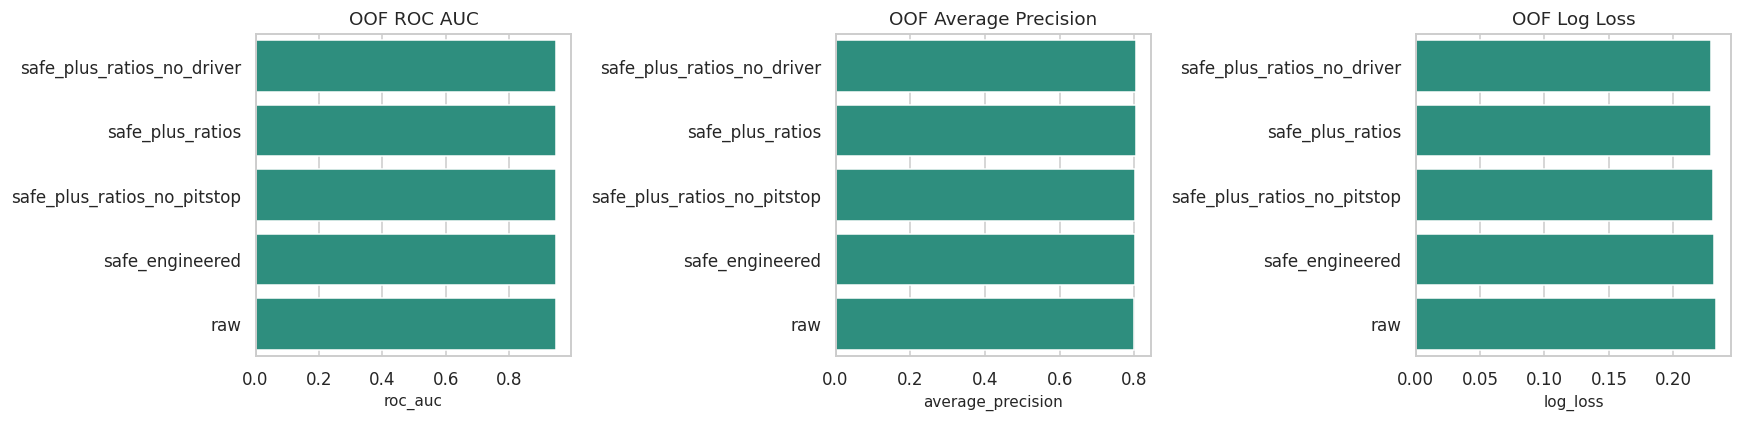

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metric_specs = [
    ("roc_auc", False, "OOF ROC AUC"),
    ("average_precision", False, "OOF Average Precision"),
    ("log_loss", True, "OOF Log Loss"),
]

for ax, (metric, ascending, title) in zip(axes, metric_specs):
    order = summary.sort_values(metric, ascending=ascending)["feature_set"]
    sns.barplot(data=summary, y="feature_set", x=metric, order=order, color=sns.color_palette("viridis", 8)[4], ax=ax)
    ax.set_title(title)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Slice Error Analysis

In [16]:
best_feature_set = summary.iloc[0]["feature_set"]
best_data = feature_set_data[best_feature_set].reset_index(drop=True)
best_oof = oof_predictions[best_feature_set]

slice_df = best_data[[TARGET, "Compound", "Stint", "RaceProgress", "TyreLife"]].copy()
slice_df["prediction"] = best_oof
slice_df["RaceProgress_bin"] = pd.qcut(slice_df["RaceProgress"], q=5, duplicates="drop")
slice_df["TyreLife_bin"] = pd.qcut(slice_df["TyreLife"], q=5, duplicates="drop")


def slice_metrics(df: pd.DataFrame, col: str, min_count: int = 100) -> pd.DataFrame:
    rows = []
    for value, part in df.groupby(col, observed=True):
        if len(part) < min_count or part[TARGET].nunique() < 2:
            continue
        metrics = evaluate_predictions(part[TARGET], part["prediction"])
        metrics.update({
            "slice": col,
            "value": str(value),
            "count": len(part),
            "target_rate": part[TARGET].mean(),
            "prediction_mean": part["prediction"].mean(),
        })
        rows.append(metrics)
    return pd.DataFrame(rows)


slice_results = pd.concat([
    slice_metrics(slice_df, "Compound"),
    slice_metrics(slice_df, "Stint"),
    slice_metrics(slice_df, "RaceProgress_bin"),
    slice_metrics(slice_df, "TyreLife_bin"),
], ignore_index=True)

slice_results.sort_values("log_loss", ascending=False)

,roc_auc,average_precision,log_loss,slice,value,count,target_rate,prediction_mean
6,0.910293,0.844382,0.361247,Stint,2,53165,0.389636,0.389842
14,0.918865,0.841884,0.339920,RaceProgress_bin,"(0.359, 0.571]",35877,0.356719,0.356592
0,0.927179,0.838001,0.315222,Compound,HARD,69940,0.326079,0.326008
7,0.921830,0.799523,0.314434,Stint,3,28126,0.294141,0.293452
20,0.947176,0.889436,0.275906,TyreLife_bin,"(22.0, 77.0]",33469,0.362156,0.362153
19,0.940095,0.817791,0.271177,TyreLife_bin,"(15.0, 22.0]",35473,0.271784,0.271813
15,0.943730,0.836032,0.262968,RaceProgress_bin,"(0.571, 1.0]",35811,0.270978,0.271220
3,0.929353,0.760154,0.260041,Compound,SOFT,15784,0.196275,0.195031
18,0.934274,0.743641,0.251620,TyreLife_bin,"(10.0, 15.0]",35785,0.197150,0.196623
13,0.937671,0.776593,0.248386,RaceProgress_bin,"(0.205, 0.359]",36212,0.199713,0.198954


## 8. Train Selected Feature Set and Submit

In [17]:
selected_feature_set = best_feature_set
selected_config = feature_set_configs[selected_feature_set]

train_selected = prepare_feature_set(train, selected_config)
test_selected = prepare_feature_set(test, selected_config)

X_train = train_selected.drop(columns=[TARGET])
y_train = train_selected[TARGET].astype("int8")
X_test = test_selected.copy()

final_preprocessor = make_preprocessor(X_train)
X_train_processed = final_preprocessor.fit_transform(X_train)
X_test_processed = final_preprocessor.transform(X_test)

final_model = LGBMClassifier(**lgbm_params)
final_model.fit(X_train_processed, y_train)

test_pred = final_model.predict_proba(X_test_processed)[:, 1]
test_pred = np.clip(test_pred, 1e-6, 1 - 1e-6)

submission = sample_submission.copy()
submission[TARGET] = test_pred
submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

comparison.to_csv(OUTPUT_DIR / "feature_validation_summary.csv", index=False)
fold_results.to_csv(OUTPUT_DIR / "feature_validation_fold_results.csv", index=False)
slice_results.to_csv(OUTPUT_DIR / "feature_validation_slice_results.csv", index=False)

print("Selected feature set:", selected_feature_set)
print("Saved:", submission_path)
submission.head()

Selected feature set: safe_plus_ratios_no_driver
Saved: /kaggle/working/submission.csv


,id,PitNextLap
0,439140,0.006827
1,439141,0.002203
2,439142,0.003025
3,439143,0.163947
4,439144,0.883381


## 9. Decision Rules

- Keep a feature set only if it improves OOF AUC or log loss and the gain is stable across folds.
- Be skeptical of tyre-ratio features if they improve fast-mode CV but fail on full-data CV or produce poor slice calibration.
- If removing `Driver` barely hurts performance, prefer the simpler model because it may generalize better.
- If removing `PitStop` hurts substantially, decide whether it is valid competition-time information before relying on it.

## LightGBM + XGBoost Ensemble


## 1. Setup

In [18]:
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10, "legend.frameon": False})

RANDOM_STATE = 42
TARGET = "PitNextLap"
ID_COL = "id"

# Use True for quick checks, then False for final ensemble evidence.
RUN_FAST = True
FAST_SAMPLE_SIZE = 180_000
N_SPLITS = 5

# If feature validation selects a different feature set, update this value.
SELECTED_FEATURE_SET = "safe_plus_ratios"

## 2. Load Data

In [19]:
def find_data_dir() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/playground-series-s6e5"),
        Path("/kaggle/input/playground-series-s6e5"),
        Path("../input/competitions/playground-series-s6e5"),
        Path("../input/playground-series-s6e5"),
        Path("data"),
        Path("../data"),
        Path("."),
    ]
    for path in candidates:
        if (path / "train.csv").exists() and (path / "test.csv").exists():
            return path
    raise FileNotFoundError("Could not find train.csv and test.csv. Update DATA_DIR manually.")


def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5:
                out[col] = out[col].astype("category")
    return out


DATA_DIR = find_data_dir()
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = reduce_memory_usage(pd.read_csv(DATA_DIR / "train.csv"))
test = reduce_memory_usage(pd.read_csv(DATA_DIR / "test.csv"))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

if RUN_FAST and len(train) > FAST_SAMPLE_SIZE:
    train_eval = (
        train.groupby(TARGET, group_keys=False)
        .apply(lambda x: x.sample(frac=min(1.0, FAST_SAMPLE_SIZE / len(train)), random_state=RANDOM_STATE))
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
else:
    train_eval = train.copy()

print(f"DATA_DIR: {DATA_DIR}")
print(f"train_eval: {train_eval.shape}")
print(f"test: {test.shape}")
print(f"target positive rate: {train_eval[TARGET].mean():.5f}")

DATA_DIR: /kaggle/input/competitions/playground-series-s6e5
train_eval: (180000, 16)
test: (188165, 15)
target positive rate: 0.19898


## 3. Feature Engineering

In [20]:
feature_set_configs = {
    "raw": {"include_safe": False, "include_ratios": False, "drop_cols": []},
    "safe_engineered": {"include_safe": True, "include_ratios": False, "drop_cols": []},
    "safe_plus_ratios": {"include_safe": True, "include_ratios": True, "drop_cols": []},
    "safe_plus_ratios_no_driver": {"include_safe": True, "include_ratios": True, "drop_cols": ["Driver"]},
    "safe_plus_ratios_no_pitstop": {"include_safe": True, "include_ratios": True, "drop_cols": ["PitStop"]},
}


def add_features(df: pd.DataFrame, include_safe: bool = True, include_ratios: bool = True) -> pd.DataFrame:
    out = df.copy()
    eps = 1e-6

    if include_safe and {"LapNumber", "RaceProgress"}.issubset(out.columns):
        out["EstimatedRaceLaps"] = out["LapNumber"] / out["RaceProgress"].clip(lower=eps)
        out["EstimatedLapsRemaining"] = out["EstimatedRaceLaps"] - out["LapNumber"]
        out["LapNumber_x_RaceProgress"] = out["LapNumber"] * out["RaceProgress"]

    if include_ratios and {"TyreLife", "LapNumber"}.issubset(out.columns):
        out["TyreLife_to_LapNumber"] = out["TyreLife"] / out["LapNumber"].clip(lower=eps)

    if include_ratios and {"TyreLife", "EstimatedRaceLaps"}.issubset(out.columns):
        out["TyreLife_to_EstimatedRaceLaps"] = out["TyreLife"] / out["EstimatedRaceLaps"].clip(lower=eps)

    if include_safe and {"LapTime (s)", "LapTime_Delta"}.issubset(out.columns):
        out["LapTime_plus_Delta"] = out["LapTime (s)"] + out["LapTime_Delta"]
        out["AbsLapTime_Delta"] = out["LapTime_Delta"].abs()

    if include_safe and {"Position", "Position_Change"}.issubset(out.columns):
        out["PreviousPositionApprox"] = out["Position"] - out["Position_Change"]
        out["AbsPosition_Change"] = out["Position_Change"].abs()

    if include_safe and "Compound" in out.columns:
        compound = out["Compound"].astype(str)
        out["IsSoft"] = (compound == "SOFT").astype("int8")
        out["IsMedium"] = (compound == "MEDIUM").astype("int8")
        out["IsHard"] = (compound == "HARD").astype("int8")
        out["IsWetOrIntermediate"] = compound.isin(["WET", "INTERMEDIATE"]).astype("int8")

    return reduce_memory_usage(out)


def prepare_feature_set(df: pd.DataFrame, feature_set: str) -> pd.DataFrame:
    config = feature_set_configs[feature_set]
    out = add_features(df, include_safe=config["include_safe"], include_ratios=config["include_ratios"])
    return out.drop(columns=[c for c in config.get("drop_cols", []) if c in out.columns])


train_model = prepare_feature_set(train_eval, SELECTED_FEATURE_SET)
test_model = prepare_feature_set(test, SELECTED_FEATURE_SET)

X = train_model.drop(columns=[TARGET])
y = train_model[TARGET].astype("int8")
X_test = test_model.copy()

print("Feature set:", SELECTED_FEATURE_SET)
print("Features:", X.shape[1])

Feature set: safe_plus_ratios
Features: 28


## 4. Preprocessing and Models

In [21]:
def get_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    features = df.drop(columns=[c for c in [TARGET, ID_COL] if c in df.columns])
    cat_cols = features.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = [c for c in features.columns if c not in cat_cols]
    return num_cols, cat_cols


def make_preprocessor(df: pd.DataFrame) -> ColumnTransformer:
    num_cols, cat_cols = get_feature_columns(df)
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ], remainder="drop")


def evaluate_predictions(y_true, y_pred) -> dict:
    y_pred = np.clip(y_pred, 1e-6, 1 - 1e-6)
    return {
        "roc_auc": roc_auc_score(y_true, y_pred),
        "average_precision": average_precision_score(y_true, y_pred),
        "log_loss": log_loss(y_true, y_pred),
    }


lgbm_params = {
    "objective": "binary",
    "n_estimators": 900 if RUN_FAST else 1800,
    "learning_rate": 0.02,
    "num_leaves": 127,
    "min_child_samples": 150,
    "subsample": 0.95,
    "colsample_bytree": 0.9,
    "reg_alpha": 1.0,
    "reg_lambda": 10.0,
    "max_bin": 255,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 700 if RUN_FAST else 1400,
    "learning_rate": 0.025,
    "max_depth": 7,
    "min_child_weight": 8,
    "subsample": 0.85,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 3.0,
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

## 5. Cross-Validate Individual Models

In [22]:
def cross_validate_model(model_name: str, model_factory) -> tuple[np.ndarray, list[dict]]:
    oof = np.zeros(len(X), dtype=np.float32)
    rows = []
    start = time.time()

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_train_raw, X_valid_raw = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        preprocessor = make_preprocessor(X_train_raw)
        X_train = preprocessor.fit_transform(X_train_raw)
        X_valid = preprocessor.transform(X_valid_raw)

        model = model_factory()
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_valid)[:, 1]
        oof[valid_idx] = pred

        scores = evaluate_predictions(y_valid, pred)
        scores.update({"model": model_name, "fold": fold})
        rows.append(scores)
        print(f"{model_name} fold {fold}: auc={scores['roc_auc']:.5f}, logloss={scores['log_loss']:.5f}")

        del preprocessor, X_train, X_valid, model
        gc.collect()

    overall = evaluate_predictions(y, oof)
    overall.update({"model": model_name, "fold": "oof", "fit_seconds": time.time() - start})
    rows.append(overall)
    print(f"{model_name} OOF: auc={overall['roc_auc']:.5f}, ap={overall['average_precision']:.5f}, logloss={overall['log_loss']:.5f}")
    return oof, rows


lgbm_oof, lgbm_rows = cross_validate_model("lightgbm", lambda: LGBMClassifier(**lgbm_params))
xgb_oof, xgb_rows = cross_validate_model("xgboost", lambda: XGBClassifier(**xgb_params))

model_results = pd.DataFrame(lgbm_rows + xgb_rows)
model_results[model_results["fold"].eq("oof")]

lightgbm fold 1: auc=0.94854, logloss=0.22650
lightgbm fold 2: auc=0.94853, logloss=0.22729
lightgbm fold 3: auc=0.94717, logloss=0.22947
lightgbm fold 4: auc=0.94613, logloss=0.23165
lightgbm fold 5: auc=0.94611, logloss=0.23183
lightgbm OOF: auc=0.94728, ap=0.80484, logloss=0.22935
xgboost fold 1: auc=0.94718, logloss=0.22969
xgboost fold 2: auc=0.94670, logloss=0.23114
xgboost fold 3: auc=0.94548, logloss=0.23307
xgboost fold 4: auc=0.94421, logloss=0.23560
xgboost fold 5: auc=0.94449, logloss=0.23531
xgboost OOF: auc=0.94560, ap=0.80005, logloss=0.23296


,roc_auc,average_precision,log_loss,model,fold,fit_seconds
5,0.947282,0.804845,0.229346,lightgbm,oof,105.927302
11,0.945602,0.800049,0.232964,xgboost,oof,45.680780


## 6. Tune Blend Weight

In [23]:
blend_rows = []
for lgbm_weight in np.linspace(0, 1, 21):
    blend_pred = lgbm_weight * lgbm_oof + (1 - lgbm_weight) * xgb_oof
    scores = evaluate_predictions(y, blend_pred)
    scores.update({
        "model": "lgbm_xgb_blend",
        "lgbm_weight": lgbm_weight,
        "xgb_weight": 1 - lgbm_weight,
    })
    blend_rows.append(scores)

blend_results = pd.DataFrame(blend_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
blend_results.head(10)

,roc_auc,average_precision,log_loss,model,lgbm_weight,xgb_weight
0,0.947288,0.804951,0.229337,lgbm_xgb_blend,0.95,0.05
1,0.947286,0.805028,0.229349,lgbm_xgb_blend,0.90,0.10
2,0.947282,0.804845,0.229346,lgbm_xgb_blend,1.00,0.00
3,0.947274,0.805057,0.229383,lgbm_xgb_blend,0.85,0.15
4,0.947254,0.805056,0.229437,lgbm_xgb_blend,0.80,0.20
5,0.947225,0.805020,0.229511,lgbm_xgb_blend,0.75,0.25
6,0.947186,0.804952,0.229605,lgbm_xgb_blend,0.70,0.30
7,0.947139,0.804848,0.229719,lgbm_xgb_blend,0.65,0.35
8,0.947082,0.804711,0.229852,lgbm_xgb_blend,0.60,0.40
9,0.947017,0.804532,0.230004,lgbm_xgb_blend,0.55,0.45


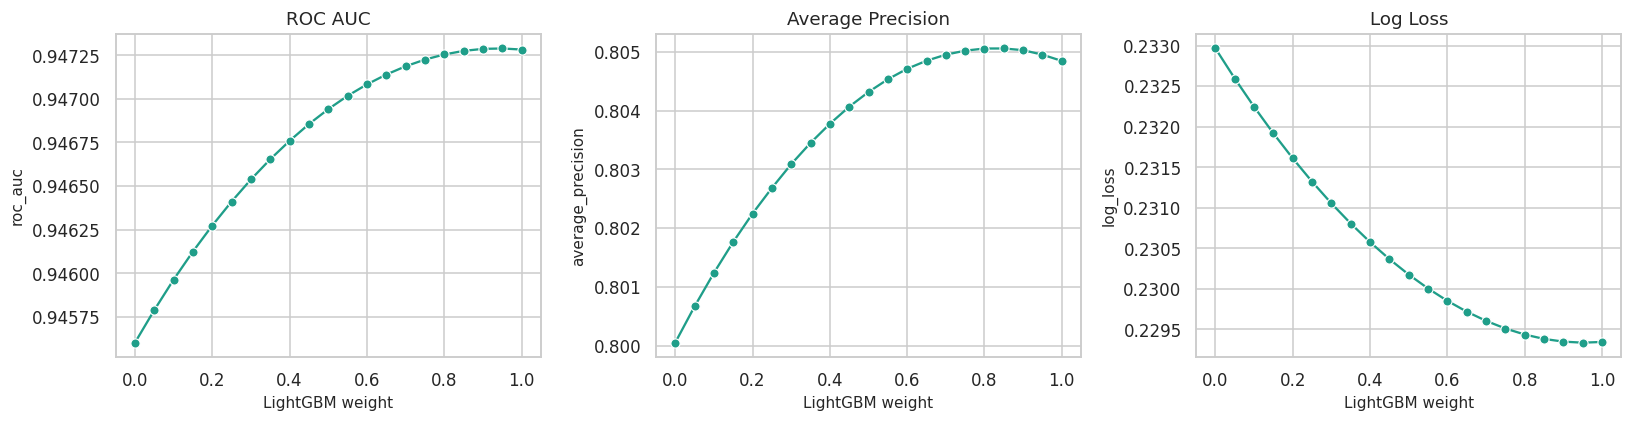

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes, ["roc_auc", "average_precision", "log_loss"], ["ROC AUC", "Average Precision", "Log Loss"]):
    sns.lineplot(data=blend_results.sort_values("lgbm_weight"), x="lgbm_weight", y=metric, marker="o", color=sns.color_palette("viridis", 8)[4], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("LightGBM weight")
plt.tight_layout()
plt.show()

## 7. Train Final Ensemble and Submit

In [25]:
best_blend = blend_results.iloc[0]
best_lgbm_weight = float(best_blend["lgbm_weight"])
best_xgb_weight = float(best_blend["xgb_weight"])

print("Best blend:")
print(best_blend)

final_preprocessor = make_preprocessor(X)
X_train_processed = final_preprocessor.fit_transform(X)
X_test_processed = final_preprocessor.transform(X_test)

final_lgbm = LGBMClassifier(**lgbm_params)
final_xgb = XGBClassifier(**xgb_params)

final_lgbm.fit(X_train_processed, y)
final_xgb.fit(X_train_processed, y)

lgbm_test_pred = final_lgbm.predict_proba(X_test_processed)[:, 1]
xgb_test_pred = final_xgb.predict_proba(X_test_processed)[:, 1]
ensemble_pred = best_lgbm_weight * lgbm_test_pred + best_xgb_weight * xgb_test_pred
ensemble_pred = np.clip(ensemble_pred, 1e-6, 1 - 1e-6)

submission = sample_submission.copy()
submission[TARGET] = ensemble_pred
submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

model_results.to_csv(OUTPUT_DIR / "ensemble_model_results.csv", index=False)
blend_results.to_csv(OUTPUT_DIR / "ensemble_blend_results.csv", index=False)

print("Saved:", submission_path)
submission.head()

Best blend:
roc_auc                    0.947288
average_precision          0.804951
log_loss                   0.229337
model                lgbm_xgb_blend
lgbm_weight                    0.95
xgb_weight                     0.05
Name: 0, dtype: object
Saved: /kaggle/working/submission.csv


,id,PitNextLap
0,439140,0.004458
1,439141,0.002995
2,439142,0.001831
3,439143,0.153502
4,439144,0.845429


## 8. Decision Rule

Use the ensemble only if its OOF score beats the best individual model by a meaningful margin or improves log loss without hurting AUC. If the best weight is close to `1.0`, the ensemble is not adding enough over tuned LightGBM.